In [14]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Goal of cell is to define variables

# --- HARDWARE CONSTANTS (Placeholders based on Sensirion flow ranges) ---
D_reactor = 0.003      # Reactor Diameter (Meters) -> 3mm column
V_reactor = 50e-6      # Reactor Volume (50 microliters converted to Liters)
dp = 100e-6            # Bead Diameter (100 microns converted to meters)
epsilon = 0.4          # Bed Porosity (Typical for packed CPG beads)
rho_f = 786.0          # Density of Acetonitrile (kg/m^3)
mu_f = 0.34e-3         # Viscosity of Acetonitrile (Pa*s)
Cp_f = 2200.0          # Specific Heat Capacity (J/kg*K)

# --- KINETIC PRIORS (Derived from Russell 2007, Chapter 3 (Detritylation Kinetics) and 
# Chapter 4 (Alcoholysis Mechanisms)) using Saccharin/NMI activated phosphoramidite kinetics ---
# Both mol_weight_reagent and viscosity of solvent account for Wilke-Chang constants

R = 8.314              # Universal Gas Constant (J/mol*K)
Ea = 45000             # Activation Energy (J/mol - estimate for coupling)
A_pre = 1.5e7          # Pre-exponential factor (Adjusted for MVM)
k_ref = 0.5            # Rate constant at T_ref (1/s)
T_ref = 298.15         # Reference Temperature (25°C in Kelvin)
dH_rxn = -50000        # Enthalpy of reaction (Exothermic J/mol)
mol_weight_reagent = 700  # g/mol (Approx for phosphoramidite) 
viscosity_acn = 0.34e-3   # Pa*s

# --- TRACKERS ---
batch_progress = 0     # Tracks amount of base pairs attached to DNA chain
yield_history = []
truncation_history = 0 # Counter for failed runs

print("Cell 1: Physical environment defined.")

Cell 1: Physical environment defined.


In [15]:
def calculate_bridges(v_s, current_bp):
    # 1. Calculate Molecular Diffusivity (Simplified Wilke-Chang)
    D_mol = (7.4e-8 * np.sqrt(2.6 * 41) * 293.15) / (viscosity_acn * (mol_weight_reagent**0.6))
    
    # 2. Update Physical Geometry
    eps_eff = epsilon * (1 - (0.005 * batch_progress))
    dp_eff = dp * (1 + (0.002 * batch_progress))
    
    # 3. Standard Dimensionless Groups
    Re = (rho_f * v_s * dp_eff) / mu_f
    Sc = mu_f / (rho_f * D_mol)
    
    # 4. Nelson-Galloway Sh Number
    Sh = (2 / (1 - (1 - eps_eff)**(1/3))) + 0.664 * (Re**0.5) * (Sc**(1/3))
    
    km = (Sh * D_mol) / dp_eff
    Pe = (v_s * 0.1) / D_mol # Peclet for 10cm tubing

     # Effectiveness Factor (Placeholder for Chain Length Penalty)
    # As chain length increases, eta decreases.
    eta = 1.0 / (1.0 + 0.05 * batch_progress) # 5% penalty per base
    
    return km, eps_eff, dp_eff, Pe, eta

In [16]:
def pfr_pulse_ode(t, x, v_flow, current_bp):

    # Goal of cell is to handle the modelling of the pulse phase of the flow occuring in the printer, including Taylor-Aris dispersion. A PFR assumption
    # which assumes unidirectional flow, is used here.
    
    # Unpack State Vector: Cb, T; y[0] = C_bulk (mol/L), y[1] = Temp (K). Cb in this case refers to the concentration of activated 
    # phosphoramidite phosphoramidite dissolved in the bulk liquid (solvent). T represents the temperature of the reactor. The 
    # PBR assumption is used to model the interaction between the solvent and the beads; as the solvent moves through the printer,
    # the activated phosphoramidite is adsorbed onto the surface of the beads, meaning that Cb drops as the solvent moves along the 
    # printer tubing.
    Cb, T = x

    # In the future, if aspects of micro or meso scales can not be reduced to variables but remain as equations, we will deal with this 
    # in the Offline Training Phase of the Observer Design using use Hyper-reduction (DEIM). In this case, we will have no choice but to
    # discretize the system
    
    # Calculate Area from initialized Diameter (Meters)
    Area_reactor = np.pi * (D_reactor / 2)**2
    
    # Convert inlet Flow (uL/min) to Volumetric Flow (m^3/s)
    Q_SI = v_flow * 1.666e-11  # conversion factor for uL/min -> m^3/s

    # Calculate interstitial Velocity (m/s)
    # Epsilon (porosity) is included to find the speed of the fluid between the beads.
    v_s = Q_SI / Area_reactor # Velocity of fluid assuming no beads
    v_int = v_s/ epsilon # Actual velocity of the fluid as it squeezes through the narrow gaps between the beads.
                         # Because the beads take up space, the fluid must move faster to maintain the same flow rate.

    # Superficial is used velocity for km because most packed-bed correlations (including Nelson-Galloway) are empirically derived and 
    # calibrated using superficial velocity to keep the formula simple. Switching to interstitial velocity would require you to recalibrate 
    # the correlation, which is scope creep.
    km, eps_eff, dp_eff, Pe, eta = calculate_bridges(v_s, batch_progress) 

    # Temperature-dependent rate constant, Intrinstic Kinetics (Arrhenius - Russell 2007)
    k_intrinsic = A_pre * np.exp(-Ea / (R * T))

    # Sum of Resistances: Condensing Micro-transport and Kinetics

    # If km << k_intrinsic, then process is mass transfer limited; if k_intrinsic << km, then process is rxn limited
    # if process is mass transfer limited, then rxn rate is very sensitive to the turbulence of the flow; if process 
    # is rxn limited, then rxn rate is very sensitive to temperature
    k_eff = 1 / ((1/km) + (1/k_intrinsic))  

    # These three variables are all related to Taylor-Aris Dispersion, which is used to model how mass travelling in a fluid disperses. Taylor dispersion is defined by a characteristic parabolic 
    # shape which forms in the fluid. The peclet number tells you how elongated this parabola is. We use the Peclet number to define the 'sharpness' of various transitions, such as a fluid shear 
    # thinning.
    arrival_time = 5.0  # Seconds it takes to travel from valve to bed
    sharpness = np.sqrt(Pe) / 2.0
    C_in_dynamic = 0.1 * (0.5 * (1 + np.tanh(sharpness * (t - arrival_time)))) # 0.1 is the inlet concentration (Russell Prior). tanh function represents analytical solution to dispersion equation.

    # Residence time calculation, Convert Flow to Velocity
    tau = (V_reactor * eps_eff) / (Q_SI * 1000) # converting m^3/s to L/s
    flow_term = (C_in_dynamic - Cb) / tau
    
    # Reaction Rate
    r = eta * k_eff * Cb
    
    # --- COUPLING (Conservation Laws) ---
    dCb_dt = flow_term - r                             # Mass balance
    dT_dt = ((-dH_rxn * r) / (rho_f * Cp_f)) * 1000    # Energy balance
    
    return [dCb_dt, dT_dt]

In [17]:
def batch_wait_ode(t, x, current_bp):

    # Goal of cell is to handle the modelling of the wait phase of the flow occuring in the printer. A batch assumption is used here to simulate how
    # the fluid is sitting and incubating in the reaction control volume.
    Cb, T = x
    # Stagnant k_m (Sherwood = 2)
    D_mol = 1e-9 # Theoretical diffusion coefficient
    km, eps_eff, dp_eff, Pe, eta = calculate_bridges(0, batch_progress)
    
    km_stagnant = (2 * D_mol) / dp_eff # In the wait phase, mass transfer coefficient is dominated by diffusion, not convection. Since v=0, the 
                                       # Sherwood number (Sh) approaches its theoretical limit of 2 for a sphere in stagnant fluid. This is also
                                       # the reason why D_mol is a different value.
    
    k_int = A_pre * np.exp(-Ea / (R * T)) # k_int has to be recalculated here because heat transfer during wait phase differs greatly compared to 
                                          # pulse phase, which has implications for T
    k_eff = 1 / ((1/km) + (1/k_int))
    
    r = eta * k_eff * Cb
    
    # NO FLOW TERM: Only reaction consumption and adiabatic heating because fluid inside printer is stagnant in this phase.
    dCb_dt = -r 
    dT_dt = ((-dH_rxn * r) / (rho_f * Cp_f))
    return [dCb_dt, dT_dt]

In [18]:
def run_full_cycle(u_flow, current_bp):
    # This cell is responsible for solving the pfr and batch models and obtaining their solutions so that they can be used in the future.
    
    # 1. PULSE PHASE: 30 seconds of flow
    t_pulse = np.linspace(0, 30, 50)
    x0_pulse = [0.0, 293.15] # Initial: Zero Conc, Room Temp
    sol_p = solve_ivp(pfr_pulse_ode, (0, 30), x0_pulse, 
                     args=(u_flow, current_bp), t_eval=t_pulse)
    
    # 2. THE HAND-OFF: Temporal Recycle
    x_mid = sol_p.y[:, -1] 
    
    # 3. WAIT PHASE: 90 seconds of stagnant incubation
    t_wait = np.linspace(30, 120, 50) # Continuing the time axis
    sol_w = solve_ivp(batch_wait_ode, (30, 120), x_mid, 
                     args=(current_bp,), t_eval=t_wait)
    
    return sol_p, sol_w

In [19]:
all_runs = [] # List of (sol_p, sol_w) tuples
yield_history = []
batch_progress = 0

# This cell is responsible for simulating the base pair addition onto a new/existing DNA chain.

for bp in range(5): # Simulating a 5-mer
    # Execute the Pulse-Wait cycle
    sol_p, sol_w = run_full_cycle(100.0, batch_progress)
    all_runs.append((sol_p, sol_w))
    
    # Yield Calculation: Check conversion at the end of the Wait phase
    final_cb = sol_w.y[0, -1]
    step_yield = (1 - (final_cb / 0.1)) * 100
    yield_history.append(step_yield)
    
    if step_yield > 98.0:
        batch_progress += 1
    else:
        print(f"Truncation at BP {bp+1}")
        break

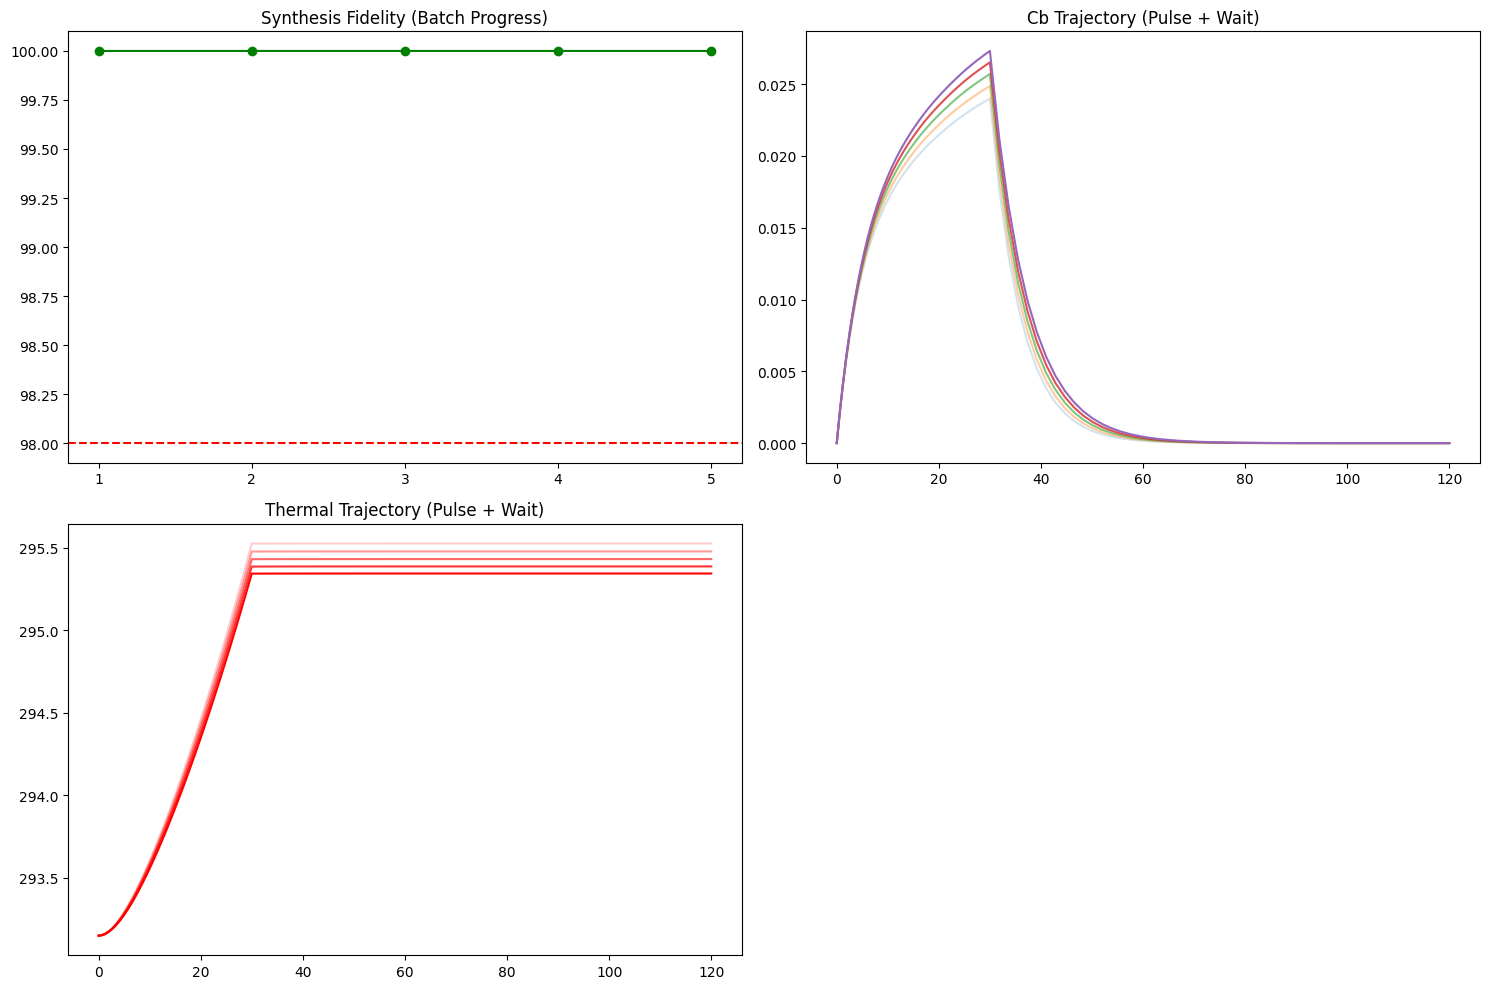

In [20]:
plt.figure(figsize=(15, 10))

# PLOT 1: Fidelity Decay (Integer Axis Fix)
plt.subplot(2, 2, 1)
plt.plot(range(1, len(yield_history) + 1), yield_history, 'go-')
plt.xticks(range(1, 6)) # Forces integer BP indices
plt.axhline(y=98.0, color='r', linestyle='--')
plt.title("Synthesis Fidelity (Batch Progress)")

# PLOT 2 & 3: Conc and Temp Trajectories (Stitching Pulse + Wait)
plt.subplot(2, 2, 2)
for i, (sp, sw) in enumerate(all_runs):
    full_t = np.concatenate([sp.t, sw.t])
    full_cb = np.concatenate([sp.y[0], sw.y[0]])
    plt.plot(full_t, full_cb, label=f"BP {i+1}", alpha=(i+1)/len(all_runs))
plt.title("Cb Trajectory (Pulse + Wait)")

plt.subplot(2, 2, 3)
for i, (sp, sw) in enumerate(all_runs):
    full_t = np.concatenate([sp.t, sw.t])
    full_temp = np.concatenate([sp.y[1], sw.y[1]])
    plt.plot(full_t, full_temp, color='red', alpha=(i+1)/len(all_runs))
plt.title("Thermal Trajectory (Pulse + Wait)")

plt.tight_layout()
plt.show()